In [1]:
import pandas as pd



# استيراد داتا car_purchasing
df = pd.read_csv(r'D:\AI-and-Machine_Learning_Diploma\Deep_Learning\Session_3\Data\car_purchasing.csv.xls', encoding='ISO-8859-1')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    str    
 1   customer e-mail      500 non-null    str    
 2   country              500 non-null    str    
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 35.3 KB


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
X = df.iloc[: , 3:-1]
y = df.iloc[:, -1]

In [6]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1))

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [8]:
model = Sequential()
model.add(Dense(10,activation = 'relu',input_dim = 5))
model.add(Dense(10,activation = 'relu'))
model.add(Dense(1,activation = 'linear'))
model.compile(loss = 'mean_squared_error',optimizer = 'adam')
model.summary()

D:\AI-and-Machine_Learning_Diploma\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs = 1000)

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1939 - val_loss: 0.1338
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0974 - val_loss: 0.0556
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0414 - val_loss: 0.0245
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0259 - val_loss: 0.0233
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0255 - val_loss: 0.0235
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0237 - val_loss: 0.0208
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0218 - val_loss: 0.0191
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0209 - val_loss: 0.0184
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0203 - val_loss: 0.0178
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0196 - val_loss: 0.0175
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0190 - val_loss: 0.0169
Epoch 12/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

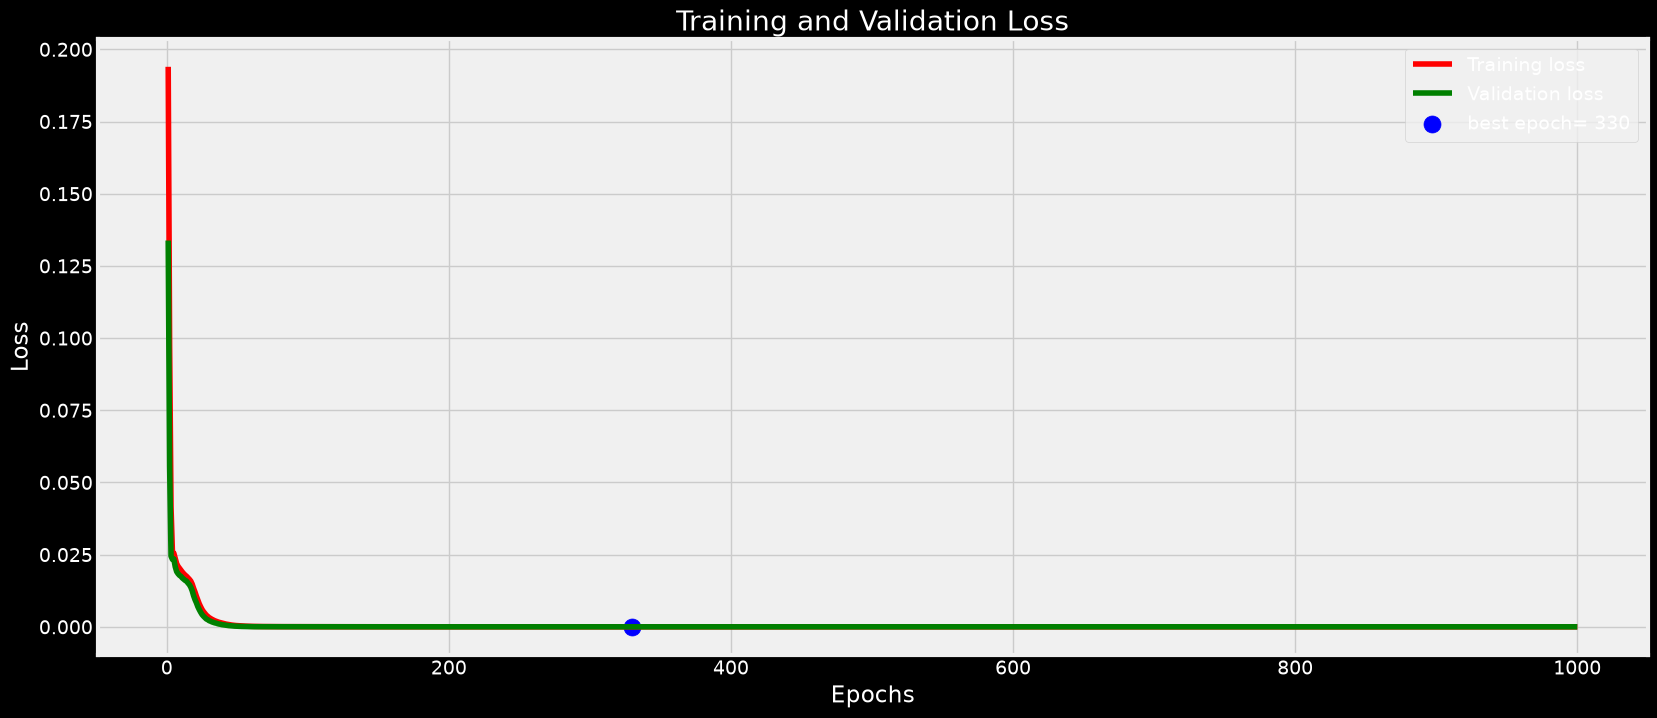

In [10]:
# Define needed variables
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = list(range(1, len(tr_loss)+1))
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout
plt.show()

In [11]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

MSE = mean_squared_error(y_test, y_pred)
print("MSE=",MSE )

MAE = mean_absolute_error(y_test, y_pred)
print("MAE=",MAE )

# R2 = r2_score(y_test, y_pred)
# print("R2 Score=",R2 )

MSE= 2.504969826242767e-07
MAE= 0.00011671899747855485
